In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-02-24 17:45:52.589988: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 17:45:52.697750: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 17:45:52.745526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740437152.827208     222 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740437152.850612     222 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-24 17:45:52.967931: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [51]:
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = 'both_hypothermia', aDropColumns=['Hypothermia', 'treatment_hypothermia']) 

/tmp/ipykernel_222/3449070138.py:6: DtypeWarning: Columns (2058,2069,2080,2082,2083,2088,2094,2098,2255,2257) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [52]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]

In [53]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [54]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(4000, activation='relu'), #6000
    layers.Dropout(0.5),#0.2
    layers.Dense(2000, activation='relu'),#2000
    layers.Dropout(0.5),#0.1
    layers.Dense(500, activation='relu'), 
    layers.Dense(200, activation='relu'), 
    layers.Dense(50, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [56]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=30, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.7872 - loss: 0.4431 - roc_auc: 0.8681 - val_accuracy: 0.7044 - val_loss: 0.6068 - val_roc_auc: 0.7763
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.7952 - loss: 0.4361 - roc_auc: 0.8692 - val_accuracy: 0.7134 - val_loss: 0.5822 - val_roc_auc: 0.7759
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.8103 - loss: 0.4126 - roc_auc: 0.8878 - val_accuracy: 0.7018 - val_loss: 0.5816 - val_roc_auc: 0.7716
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.7964 - loss: 0.4528 - roc_auc: 0.8623 - val_accuracy: 0.7005 - val_loss: 0.6508 - val_roc_auc: 0.7740
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.7990 - loss: 0.4192 - roc_auc: 0.8831 - val_accuracy: 0.7057 - val_loss: 0.6175 - val_roc_auc: 0.7700
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8250 - loss: 0.4090 - roc_auc: 0.8842 - val_accuracy: 0.7121 - val_loss: 0.6170 - val_roc_auc:

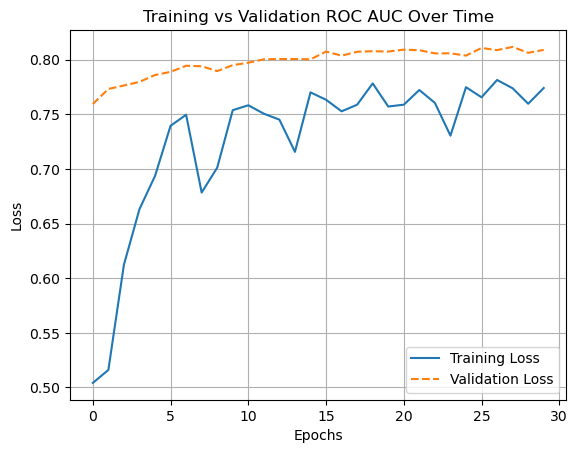

In [40]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ROC AUC Score: 0.7682


In [20]:
y_pred_probs.T[0, :]

array([0.5581573 , 0.58710545, 0.27294993, 0.87569696, 0.39354992,
       0.47886062, 0.68057233, 0.77723676, 0.2716288 , 0.54225194,
       0.44640675, 0.23781827, 0.8410868 , 0.5296747 , 0.5866726 ,
       0.27835366, 0.3114831 , 0.3509452 , 0.7537851 , 0.63434577,
       0.5175084 , 0.61719626, 0.36909446, 0.81791115, 0.50520027,
       0.89699626, 0.72609156, 0.75509095, 0.9303954 , 0.55415624,
       0.613268  , 0.7457361 , 0.72020644, 0.49819732, 0.66095555,
       0.42011395, 0.928656  , 0.824194  , 0.7220193 , 0.79184955,
       0.59877974, 0.5286867 , 0.46337864, 0.515332  , 0.41243866,
       0.5659714 , 0.27757418, 0.52723   , 0.6107241 , 0.4027312 ,
       0.58839756, 0.7104465 , 0.8852528 , 0.8879742 , 0.66539973,
       0.9262446 , 0.5749436 , 0.30399302, 0.7521817 , 0.882321  ,
       0.8298511 , 0.5632527 , 0.8017699 , 0.3932013 , 0.9535283 ,
       0.35581633, 0.36410668, 0.70458114, 0.30971134, 0.50718486,
       0.50288343, 0.9713504 , 0.22770804, 0.42543268, 0.69972

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Optimization terminated successfully.
         Current function value: 0.653619
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.653428
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.6881004556967127
p-value: 0.7088933209690582
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1796
Model:                          Logit   Df Residuals:                     1792
Method:                           MLE   Df Model:                            3
Date:                Mon, 24 Feb 2025   Pseudo R-squ.:                 0.01831
Time:                        18:20:45   Log-Likelihood:                -1173.9
converged:                       True   LL-Null:                       -1195.8
Covariance Type:       

0.7088933209690582

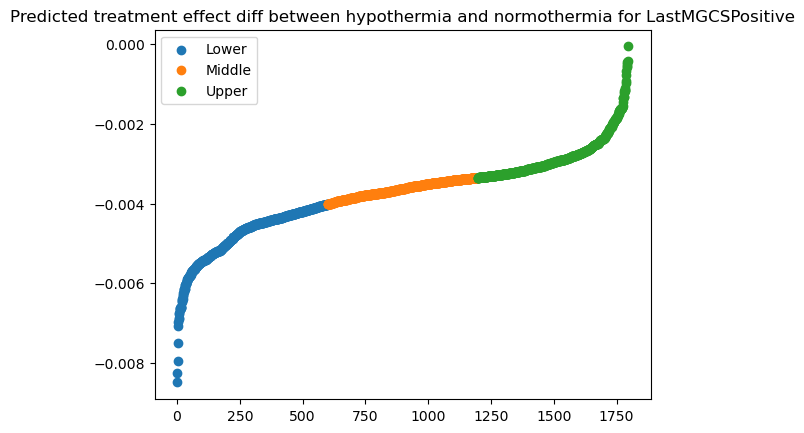

In [42]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPositive', aGroup = 'bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Optimization terminated successfully.
         Current function value: 0.665600
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.663309
         Iterations 9
Likelihood ratio of test results:
Chi square statistic: 3.5333376632751197
p-value: 0.17090134280469155
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  771
Model:                          Logit   Df Residuals:                      767
Method:                           MLE   Df Model:                            3
Date:                Mon, 24 Feb 2025   Pseudo R-squ.:               0.0005242
Time:                        18:20:59   Log-Likelihood:                -513.18
converged:                       True   LL-Null:                       -513.45
Covariance Type:      

0.17090134280469155

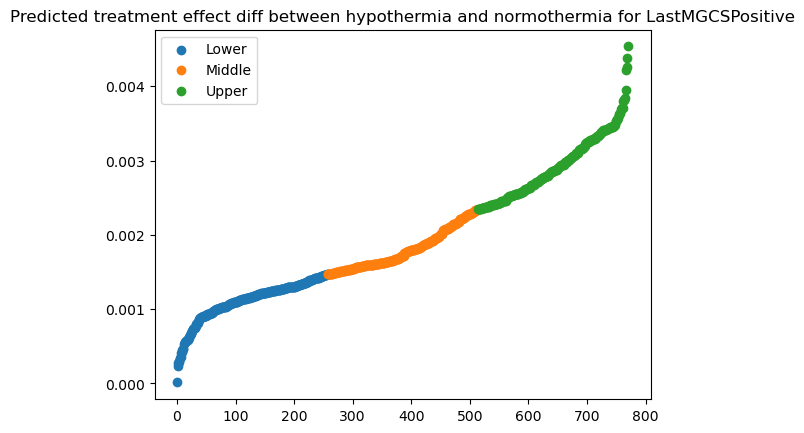

In [44]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPositive', aGroup = 'bin__treatment_defibrillation', aUseNeuralNetwork = True, aByGroup = True)

In [193]:
[x for x in myPredictorsDf.columns if 'treatment' in x]

['treatment_5-10 cm H2O',
 'treatment_50-60%',
 'treatment_> 15 cm H2O',
 'treatment_>250 cc/hr',
 'treatment_>90%',
 'treatment_ACE inhibitor',
 'treatment_AFB',
 'treatment_BAL/PBS',
 'treatment_C A V H D',
 'treatment_C V V H D',
 'treatment_CABG',
 'treatment_CPAP/PEEP therapy',
 'treatment_CT scan',
 'treatment_Cardiac surgery consultation',
 'treatment_Cardiology consultation',
 "treatment_D5 Lactated Ringer's",
 'treatment_D50',
 'treatment_EEG',
 'treatment_EEG monitoring',
 'treatment_ERCP',
 'treatment_GI therapies',
 'treatment_Gastroenterology consultation',
 'treatment_HMG-CoA reductase inhibitor',
 'treatment_ICH/ cerebral infarct',
 'treatment_IV',
 'treatment_IV furosemide',
 'treatment_IVIG administration',
 'treatment_Infectious Disease consultation',
 "treatment_Lactated Ringer's administration",
 "treatment_Lactated Ringer's solution",
 'treatment_MRI - head',
 'treatment_Nephrology consultation',
 'treatment_Neurology consultation',
 'treatment_Neurosurgery consult